## Reasoning Patch

In [ ]:
%load_ext autoreload
%autoreload 2

### Overview

### Set-up

In [2]:
import torch
import seaborn as sns
import gc
from tqdm import tqdm, trange
from datasets import Dataset
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup, AutoModelForCausalLM, AutoTokenizer, Mxfp4Config
from torch.nn import CrossEntropyLoss

import pyvene
from pyvene import (
    IntervenableModel,
    VanillaIntervention,
    CollectIntervention,
    BoundlessRotatedSpaceIntervention,
    RepresentationConfig,
    IntervenableConfig,
)
from pyvene import set_seed, count_parameters

nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.


In [3]:
model_id = "openai/gpt-oss-20b"
path = "/nas/ucb/daniel_d_kang/huggingface/cache"
quantization_config = Mxfp4Config(dequantize=True)
model_kwargs = dict(
    attn_implementation="eager",
    dtype=torch.bfloat16,
    quantization_config=quantization_config,
    use_cache=False,
    device_map="cuda:1",
    cache_dir=path,
)

model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_id, cache_dir=path)
tokenizer.pad_token = tokenizer.eos_token

## Test Chat and Completion

In [5]:
# from openai_harmony import (
#     Author,
#     Conversation,
#     DeveloperContent,
#     HarmonyEncodingName,
#     Message,
#     Role,
#     SystemContent,
#     ToolDescription,
#     load_harmony_encoding,
#     ReasoningEffort
# )
 
# encoding = load_harmony_encoding(HarmonyEncodingName.HARMONY_GPT_OSS)
 
# system_message = (
#     SystemContent.new()
#         .with_reasoning_effort(ReasoningEffort.HIGH)
#         .with_conversation_start_date("2025-06-28")
# )
 
# convo = Conversation.from_messages(
#     [
#         Message.from_role_and_content(Role.SYSTEM, system_message),
#         Message.from_role_and_content(Role.USER, "What is 4153+7285"),
#     ]
# )
 
# tokens = encoding.render_conversation_for_completion(convo, Role.ASSISTANT)
# print(tokenizer.decode(tokens))
# print(tokenizer.convert_ids_to_tokens(tokens))
# tokens_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
# print(tokens_tensor.shape)

In [ ]:
# output = model.generate(tokens_tensor, max_new_tokens=150)
# print(tokenizer.decode(output[0]))

In [7]:
# input_convo = Conversation.from_messages(
#     [
#         Message.from_role_and_content(Role.SYSTEM, system_message),
#         Message.from_role_and_content(Role.USER, "What is 1+4?"),
#         Message.from_role_and_content(
#             Role.ASSISTANT,
#             'The user: "What is 1+4?" Simple addition. The correct sum is 5. As a language model, we reply: "5". We should keep answer short.',
#         ).with_channel("analysis"),
#     ]
# )
# input_tokens = encoding.render_conversation_for_completion(input_convo, Role.ASSISTANT)
# print(tokenizer.decode(input_tokens))
# input_tokens_tensor = torch.tensor(input_tokens).unsqueeze(0).to(device)
# output = model.generate(input_tokens_tensor, max_new_tokens=100)
# print(tokenizer.decode(output[0]))
# output_tokens = tokenizer.convert_ids_to_tokens(output[0])
# print(output_tokens)
# print(output_tokens[75:].index('4'))
# print(output_tokens[84:97])

## Prompt Templates

In [6]:
two_digit_reasoning_template = f'''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 1TEN1ONE+2TEN2ONE?<|end|><|start|>assistant<|channel|>analysis<|message|>The user: "What is 1TEN1ONE+2TEN2ONE?" Simple addition. 1TEN0 + 2TEN0 ='''

source = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-06-28

Reasoning: high

# Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 1+4?<|end|><|start|>assistant<|channel|>analysis<|message|>The user: "What is 1+4?" Simple addition. The correct sum is '''

factual_answer = '8. As a language model, we reply: "8". We should keep answer short.<|end|><|start|>assistant<|channel|>final<|message|>8<|return|>'

counterfactual_answer = '5. As a language model, we reply: "5". We should keep answer short.<|end|><|start|>assistant<|channel|>final<|message|>5<|return|>'

base_tokens = tokenizer(two_digit_reasoning_template, return_tensors="pt").to(device)
# source_tokens = tokenizer(source, return_tensors="pt").to(device)

# Figure out intervention token positions
print(tokenizer.decode(base_tokens["input_ids"][0][90:113]))


1TEN1ONE+2TEN2ONE?" Simple addition. 1TEN0 + 2TEN0 =


In [9]:
# output = model.generate(base_tokens['input_ids'], max_new_tokens=150)
# print(tokenizer.decode(output[0]))

## Create Dataset

In [10]:
import random

# Generate two lists of 100 tuples, each containing two one-digit numbers as strings
list1 = [(random.randint(1, 9), random.randint(0, 9), random.randint(1, 9), random.randint(0, 9)) for i in range(100)]
list2 = [(random.randint(1, 9), random.randint(0, 9), random.randint(1, 9), random.randint(0, 9)) for i in range(100)]

list1_sums = [num1*10 + num2 + num3*10 + num4 for num1, num2, num3, num4 in list1]
list2_sums = [num1*10 + num2 + num3*10 + num4 for num1, num2, num3, num4 in list2]

factual_sums = [[a1*10 + a2 + a3*10 + a4, b1*10 + b2 + b3*10 + b4] for (a1, a2, a3, a4), (b1, b2, b3, b4) in zip(list1, list2)]

num_swap_sums = [[a1*10 + a2 + b3*10 + b4, b1*10 + b2 + a3*10 + a4] for (a1, a2, a3, a4), (b1, b2, b3, b4) in zip(list1, list2)]

digit_swap_sums = [[a1*10 + b2 + a3*10 + b4, b1*10 + a2 + b3*10 + a4] for (a1, a2, a3, a4), (b1, b2, b3, b4) in zip(list1, list2)]

ind_swap_sums = [[a1*10 + a2 + a3*10 + b4, a1*10 + a2 + b3*10 + a4, a1*10 + b2 + a3*10 + a4, b1*10 + a2 + a3*10 + a4] for (a1, a2, a3, a4), (b1, b2, b3, b4) in zip(list1, list2)]

ds = zip(list1, list2, factual_sums, num_swap_sums, digit_swap_sums, ind_swap_sums)

print("List 1 (first 10 tuples):", list1[:10])
print("List 2 (first 10 tuples):", list2[:10])
print(f"Length of list1: {len(list1)}")
print(f"Length of list2: {len(list2)}")

print("Dataset (first 10 tuples):", list(ds)[:10])
print(len(list(ds)))


List 1 (first 10 tuples): [(7, 9, 2, 8), (1, 1, 7, 3), (9, 0, 5, 6), (1, 9, 3, 5), (5, 3, 7, 0), (8, 2, 3, 0), (5, 9, 3, 1), (2, 1, 2, 0), (5, 9, 4, 6), (8, 1, 3, 7)]
List 2 (first 10 tuples): [(5, 2, 7, 4), (8, 2, 2, 3), (6, 0, 7, 4), (6, 9, 3, 2), (1, 1, 9, 3), (5, 9, 2, 1), (6, 7, 9, 6), (6, 6, 1, 0), (7, 2, 3, 0), (5, 2, 5, 8)]
Length of list1: 100
Length of list2: 100
Dataset (first 10 tuples): [((7, 9, 2, 8), (5, 2, 7, 4), [107, 126], [153, 80], [96, 137], [103, 157, 100, 87]), ((1, 1, 7, 3), (8, 2, 2, 3), [84, 105], [34, 155], [85, 104], [84, 34, 85, 154]), ((9, 0, 5, 6), (6, 0, 7, 4), [146, 134], [164, 116], [144, 136], [144, 166, 146, 116]), ((1, 9, 3, 5), (6, 9, 3, 2), [54, 101], [51, 104], [51, 104], [51, 54, 54, 104]), ((5, 3, 7, 0), (1, 1, 9, 3), [123, 104], [146, 81], [124, 103], [126, 143, 121, 83]), ((8, 2, 3, 0), (5, 9, 2, 1), [112, 80], [103, 89], [120, 72], [113, 102, 119, 82]), ((5, 9, 3, 1), (6, 7, 9, 6), [90, 163], [155, 98], [93, 160], [95, 150, 88, 100]), ((2, 1

In [11]:
# counterfactual_1 = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
# Knowledge cutoff: 2024-06
# Current date: 2025-06-28

# Reasoning: high

# # Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 3+5?<|end|><|start|>assistant<|channel|>analysis<|message|>The user: "What is 1+5?" Simple addition. The correct sum is '''

# counterfactual_2 = '''<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
# Knowledge cutoff: 2024-06
# Current date: 2025-06-28

# Reasoning: high

# # Valid channels: analysis, commentary, final. Channel must be included for every message.<|end|><|start|>user<|message|>What is 3+5?<|end|><|start|>assistant<|channel|>analysis<|message|>The user: "What is 3+4?" Simple addition. The correct sum is '''

# counterfactual_1_tokens = tokenizer(counterfactual_1, return_tensors="pt").to(device)
# counterfactual_2_tokens = tokenizer(counterfactual_2, return_tensors="pt").to(device)

# print(tokenizer.decode(model.generate(counterfactual_1_tokens["input_ids"], max_new_tokens=20)[0]))
# print(tokenizer.decode(model.generate(counterfactual_2_tokens["input_ids"], max_new_tokens=20)[0]))

## Model Structure

In [12]:
# # Print all modules within the GptOssForCausalLM model
# print("Model structure:")
# print(model)
# # print("\n" + "="*50 + "\n")

# # Print named modules
# print("Named modules:")
# for name, module in model.named_modules():
#     print(f"{name}: {type(module).__name__}")
# print("\n" + "="*50 + "\n")

# # Print top-level attributes
# print("Top-level model attributes:")
# for attr_name in dir(model):
#     if not attr_name.startswith('_'):
#         attr = getattr(model, attr_name)
#         if hasattr(attr, '__class__') and 'torch.nn' in str(type(attr)):
#             print(f"{attr_name}: {type(attr)}")

## Manual Intervention for Non-Pyvene Models

In [5]:
def print_input_shape_hook(module, input, output):
    print(f"Hook fired on module: {module.__class__.__name__}")
    print(f"Input shape: {input[0].shape}")

def print_output_shape_hook(module, input, output):
    print(f"Hook fired on module: {module.__class__.__name__}")
    print(f"Output shape: {output.shape}")

def patch_input_hook(module, input, output):
    """
    A forward pre-hook function to inspect and modify the input arguments.
    `module`: The module to which the hook is attached.
    `args`: A tuple containing the input tensors for the module's forward method.
    
    Returns:
        A tuple of modified arguments.
    """
    
    # Define your patching logic here
    # Example: Invert the `input_ids` tensor
    modified_output = torch.zeros_like(output)
    print(modified_output)

    # The hook must return the modified input as a tuple
    return modified_output

activations = []

def cache_hook(module, input, output):
    print(f"Hook fired on module: {module.__class__.__name__}")
    print(f"Input shape: {input[0].shape}")
    activations.append(input[0])

In [6]:
# Access the specific sub-module
# For distilgpt2, the attention layers are nested
cache_hook_handles = []
for layer in range(len(model.model.layers)):
    resid_module = model.model.layers[layer]
    cache_hook_handle = resid_module.register_forward_hook(cache_hook)
    cache_hook_handles.append(cache_hook_handle)

# Register the hook on the attention module
# output_hook_handle = attention_module.register_forward_hook(print_output_shape_hook)

# Create a sample input
inputs = tokenizer("A B C D E", return_tensors="pt").to(device)

# Perform a forward pass
with torch.no_grad(): # Use no_grad for inference to avoid computation of gradients
    output = model(**inputs)

print(f"Model hidden size: {model.config.hidden_size}")
print(tokenizer.decode(inputs["input_ids"][0]))
print(tokenizer.decode(output.logits.argmax(dim=-1)[0][-1]))

Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape: torch.Size([1, 5, 2880])
Hook fired on module: GptOssDecoderLayer
Input shape

In [7]:
for layer in range(len(model.model.layers)):
    cache_hook_handles[layer].remove()

In [9]:
print(activations)
activations_tensor = torch.cat(activations, dim=0)
average_activations = activations_tensor.mean(dim=0).mean(dim=0)
print(average_activations.shape)
print(average_activations)

[tensor([[[ 0.1904,  0.4941,  0.6875,  ..., -0.0522,  0.0040,  0.0806],
         [-0.4785,  0.0972,  0.6836,  ...,  0.0016,  0.0291, -0.1436],
         [-0.3887, -0.2617, -0.2344,  ...,  0.0231,  0.0167,  0.0122],
         [-0.2695,  0.4766,  0.3184,  ..., -0.0173,  0.0299, -0.0510],
         [-0.2910,  0.4414,  0.3320,  ..., -0.0074,  0.0688,  0.0471]]],
       device='cuda:1', dtype=torch.bfloat16), tensor([[[ 2.4609e-01,  3.2812e-01,  7.5391e-01,  ..., -5.7373e-02,
           3.9062e-03,  4.0527e-02],
         [-5.3906e-01,  4.6289e-01,  1.7266e+00,  ..., -9.7656e-02,
          -2.9785e-02, -4.7852e-01],
         [-7.1875e-01,  2.4805e-01,  3.7109e-01,  ..., -5.3711e-02,
          -1.5137e-01,  1.2891e-01],
         [-4.6875e-01,  1.6016e+00,  1.2578e+00,  ...,  1.0254e-01,
           8.5449e-04, -3.4766e-01],
         [-6.3281e-01,  6.4844e-01,  9.2188e-01,  ...,  4.2725e-02,
           6.4941e-02, -6.6406e-02]]], device='cuda:1', dtype=torch.bfloat16), tensor([[[ 0.3516,  0.4707, 

### Boundless DAS on Position-aligned Tokens

Configure and Load Model

In [16]:
def intervene_config(model_type, component_unit, layer):
    config = IntervenableConfig(
        model_type=model_type,
        representations=[
            RepresentationConfig(
                layer,              # layer
                component_unit,  # intervention type
            ) # for pre_layer in range(layer)] + [
            # RepresentationConfig(
            #     pre_layer,              # layer
            #     component_unit,  # intervention type
            # ) for pre_layer in range(layer)] + [
            # RepresentationConfig(
            #     layer,              # layer
            #     component_unit,  # intervention type
            # ),
        ],
        intervention_types=[VanillaIntervention]#  * layer, [VanillaIntervention] * layer +  + [CollectIntervention] * layer
    )
    return config

In [17]:
layer = 12
config = intervene_config(
    type(model), "block_output", layer
)
intervenable = IntervenableModel(config, model)
intervenable.set_device(device)
intervenable.disable_model_gradients()

## One-Digit Patching (one prompt)

In [18]:
# import json

# # Read the patch JSON file
# with open("/nas/ucb/daniel_d_kang/entity-reps/logic/output/reasoning_patch/patch.json", "r") as f:
#     patch_data = json.load(f)

# print(patch_data)


# for tok_pos in range(84,97):
#     with torch.no_grad():
#         _, counterfactual_outputs = intervenable(
#             base={"input_ids": base_tokens["input_ids"]},
#             sources=[{"input_ids": source_tokens["input_ids"]}],
#             unit_locations={"sources->base": tok_pos},  # intervene on 2nd to last token
#         )
#     print(f"prediction for token {tok_pos}: {tokenizer.decode(counterfactual_outputs.logits[0,-1].argmax(dim=-1))}")
#     patch_data[str(layer)][str(tok_pos)] = tokenizer.decode(counterfactual_outputs.logits[0,-1].argmax(dim=-1))

# with open("/nas/ucb/daniel_d_kang/entity-reps/logic/output/reasoning_patch/patch.json", "w") as f:
#     json.dump(patch_data, f, indent=2)


## Two-Digit Patching (Whole Dataset)

In [ ]:
import json
import csv

csv_file_path = "/nas/ucb/daniel_d_kang/entity-reps/logic/output/reasoning_patch/patch_double_digit_reasoning.csv"
with open(csv_file_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    # Write header
    writer.writerow(["layer", "token_position", "token", "base_addition", "source_addition", "prediction", "output", "factual_sum", "num_swap_sum", "digit_swap_sum", "ind_swap_sum"])

iter = 0
for base_nums, source_nums, factual_sum, num_swap_sum, digit_swap_sum, ind_swap_sum in zip(list1, list2, factual_sums, num_swap_sums, digit_swap_sums, ind_swap_sums):
    if iter > 10:
        break
    iter += 1
    a1ten, a1one, a2ten, a2one = base_nums
    b1ten, b1one, b2ten, b2one = source_nums
    base = two_digit_reasoning_template.replace("1TEN", f"{a1ten}").replace("1ONE", f"{a1one}").replace("2TEN", f"{a2ten}").replace("2ONE", f"{a2one}")
    source = two_digit_reasoning_template.replace("1TEN", f"{b1ten}").replace("1ONE", f"{b1one}").replace("2TEN", f"{b2ten}").replace("2ONE", f"{b2one}")
    base_tokens = tokenizer(base, return_tensors="pt").to(device)
    source_tokens = tokenizer(source, return_tensors="pt").to(device)
    print(tokenizer.convert_ids_to_tokens(base_tokens["input_ids"][0][84:97]))

    for tok_pos in range(84,97):
        output_str = ""
        pred_str = ""
        base_tokens_copy = base_tokens["input_ids"].clone()
        source_tokens_copy = source_tokens["input_ids"].clone()
        print(f"tok_pos: {tok_pos}")
        token = tokenizer.decode(base_tokens_copy[0][tok_pos])
        print(f"intervene token: {token}")
        while pred_str != "<|return|>":
            with torch.no_grad():
                _, counterfactual_outputs = intervenable(
                    base={"input_ids": base_tokens_copy},
                    sources=[{"input_ids": source_tokens_copy}],
                    unit_locations={"sources->base": tok_pos},  # intervene on 2nd to last token
                )
            pred_tok = counterfactual_outputs.logits[0,-1].argmax(dim=-1)
            if pred_tok.item() == 200002:
                break
            pred_str = tokenizer.decode(pred_tok)
            output_str += pred_str
            base_tokens_copy = torch.cat([base_tokens_copy, pred_tok.unsqueeze(0).unsqueeze(0)], dim=1)
            source_tokens_copy = torch.cat([source_tokens_copy, pred_tok.unsqueeze(0).unsqueeze(0)], dim=1)
        print(f"prediction: {pred_str}")
        # print(f"base_tokens_copy: {tokenizer.decode(base_tokens_copy[0])}")
        with open(csv_file_path, "a", newline="") as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow([layer, tok_pos, token, f"{a1ten}{a1one}+{a2ten}{a2one}", f"{b1ten}{b1one}+{b2ten}{b2one}", pred_str, output_str.replace("\n", "\\n"), factual_sum, num_swap_sum, digit_swap_sum, ind_swap_sum])


['79', '+', '28', '?"', 'ĠSimple', 'Ġaddition', '.', 'Ġ', '70', 'Ġ+', 'Ġ', '20', 'Ġ=']
tok_pos: 84
intervene token: 79
prediction: ?
tok_pos: 85
intervene token: +
prediction: .
tok_pos: 86
intervene token: 28
prediction: .
tok_pos: 87
intervene token: ?"
prediction: .
tok_pos: 88
intervene token:  Simple
prediction: .
tok_pos: 89
intervene token:  addition
prediction: .
tok_pos: 90
intervene token: .
prediction: .
tok_pos: 91
intervene token:  
prediction: .
tok_pos: 92
intervene token: 70
prediction: .
tok_pos: 93
intervene token:  +
prediction: .
tok_pos: 94
intervene token:  
prediction: .
tok_pos: 95
intervene token: 20
prediction: .
tok_pos: 96
intervene token:  =
prediction: .
['11', '+', '73', '?"', 'ĠSimple', 'Ġaddition', '.', 'Ġ', '10', 'Ġ+', 'Ġ', '70', 'Ġ=']
tok_pos: 84
intervene token: 11
prediction: .
tok_pos: 85
intervene token: +
prediction: .
tok_pos: 86
intervene token: 73
prediction: .
tok_pos: 87
intervene token: ?"
prediction: .
tok_pos: 88
intervene token:  Simple


## Visualize One-Digit JSON Results

['3', '+', '5', '?"', 'ĠSimple', 'Ġaddition', '.', 'ĠThe', 'Ġcorrect', 'Ġsum', 'Ġis', 'Ġ']


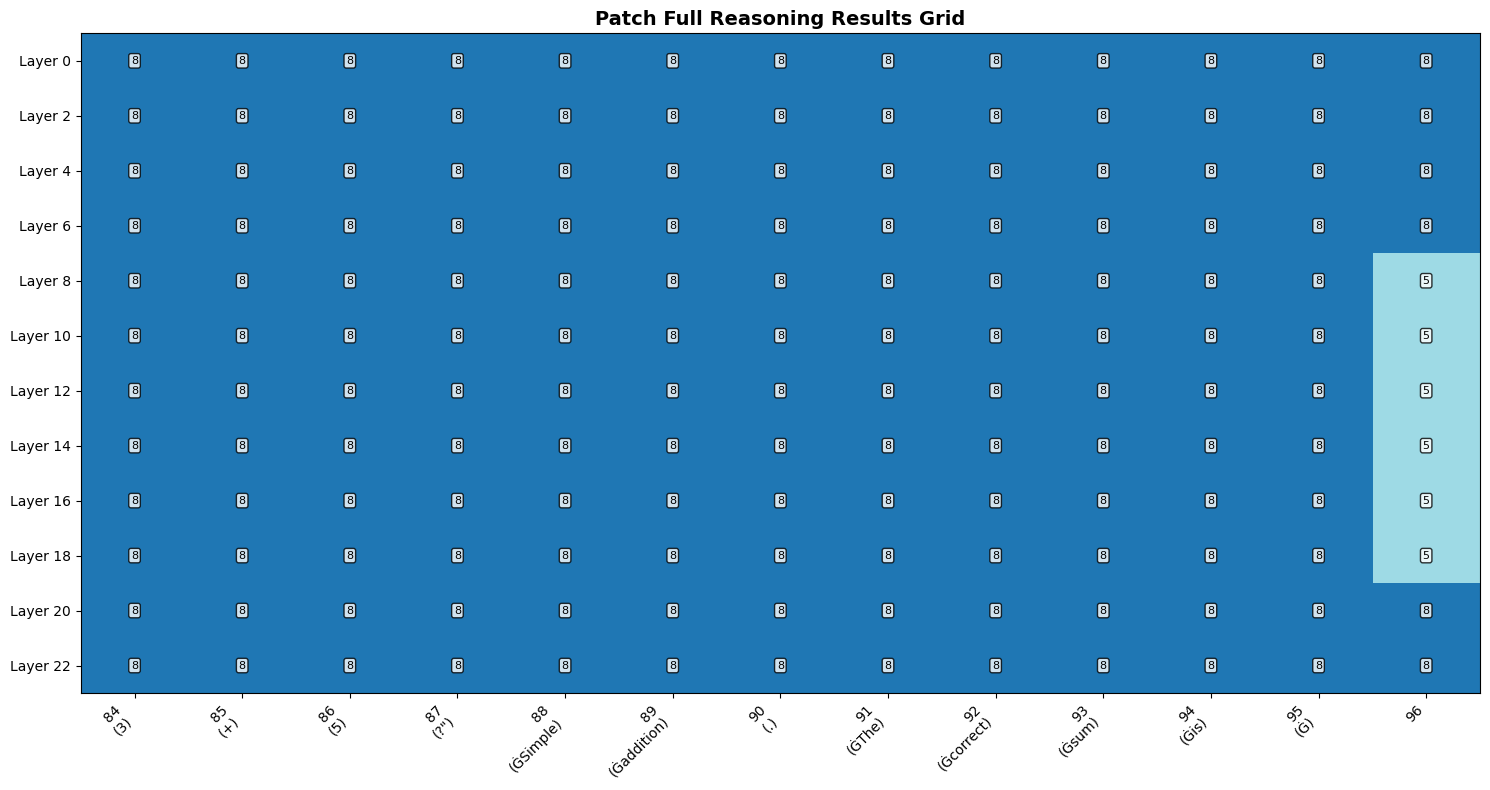

In [ ]:
labels = tokenizer.convert_ids_to_tokens(base_tokens["input_ids"][0][84:96])
print(labels)
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read the patch_full_reasoning JSON file
with open("/nas/ucb/daniel_d_kang/entity-reps/logic/output/reasoning_patch/patch_full_reasoning.json", "r") as f:
    patch_full_data = json.load(f)

# Create a DataFrame for visualization
layers = sorted(patch_full_data.keys(), key=int)
tok_positions = sorted(set().union(*[patch_full_data[layer].keys() for layer in layers]), key=int)

# Create a grid with layers as rows and token positions as columns
grid_data = []
for layer in layers:
    row = []
    for tok_pos in tok_positions:
        if tok_pos in patch_full_data[layer]:
            row.append(patch_full_data[layer][tok_pos])
        else:
            row.append("")
    grid_data.append(row)

# Create column labels using the token labels
col_labels = []
for tok_pos in tok_positions:
    tok_idx = int(tok_pos) - 84  # Adjust for the starting position
    if 0 <= tok_idx < len(labels):
        col_labels.append(f"{tok_pos}\n({labels[tok_idx]})")
    else:
        col_labels.append(str(tok_pos))

# Create DataFrame
df = pd.DataFrame(grid_data, index=[f"Layer {layer}" for layer in layers], columns=col_labels)

# Create a visualization
fig, ax = plt.subplots(figsize=(15, 8))

# Create a color-coded heatmap where each unique value gets a different color
# First, flatten all values and create a mapping
all_values = [val for row in grid_data for val in row if val != ""]
unique_values = list(set(all_values))
color_map = {val: i for i, val in enumerate(unique_values)}

# Create numeric grid for heatmap
numeric_grid = []
for row in grid_data:
    numeric_row = []
    for val in row:
        if val == "":
            numeric_row.append(-1)  # Use -1 for empty cells
        else:
            numeric_row.append(color_map[val])
    numeric_grid.append(numeric_row)

# Create heatmap
im = ax.imshow(numeric_grid, cmap='tab20', aspect='auto')

# Add text annotations
for i, layer in enumerate(layers):
    for j, tok_pos in enumerate(tok_positions):
        text = grid_data[i][j]
        if text:
            ax.text(j, i, text, ha="center", va="center", fontsize=8, 
                   bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# Set labels and title
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha='right')
ax.set_yticks(range(len(layers)))
ax.set_yticklabels([f"Layer {layer}" for layer in layers])
ax.set_title("Patch Full Reasoning Results Grid", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


